In [1]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	Abrir as imagens coloridas e mostrar a imagem e seus histogramas (separados) cada canal de cor. Considerar os seguintes sistemas de cores:
a.	RGB
b.	HSV ou HSI
c.	Lab


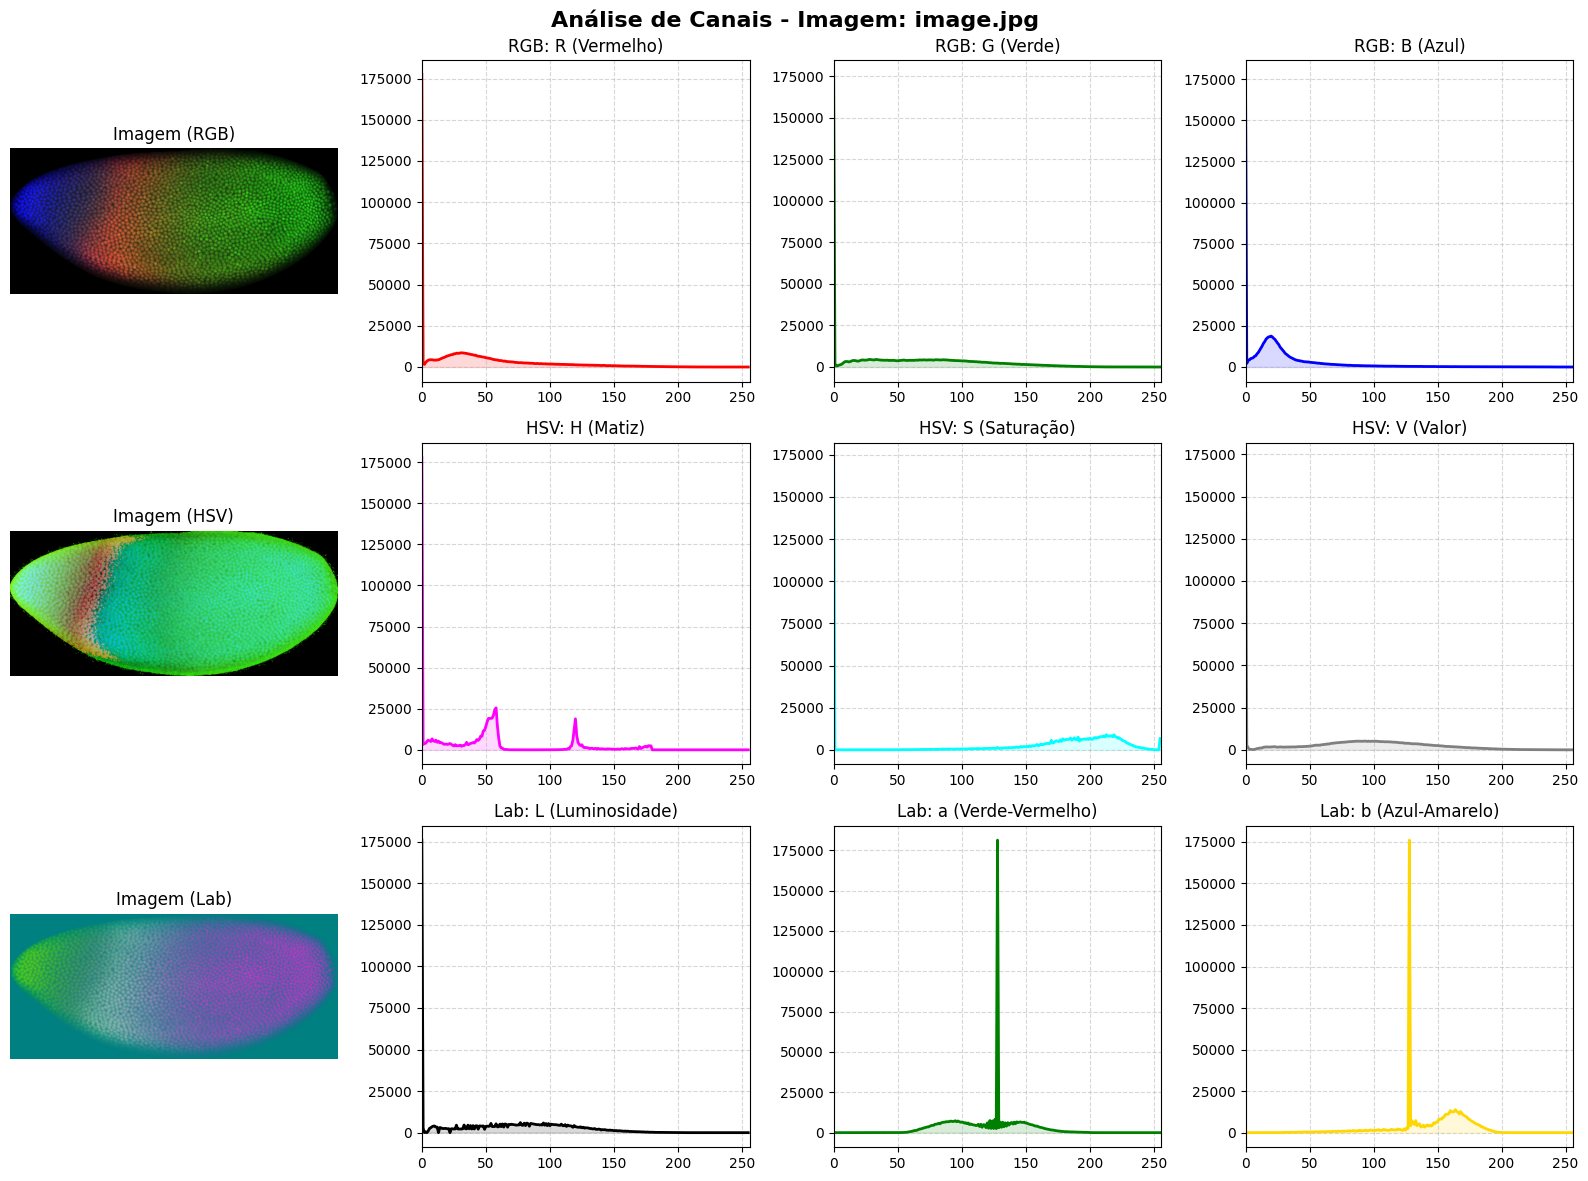

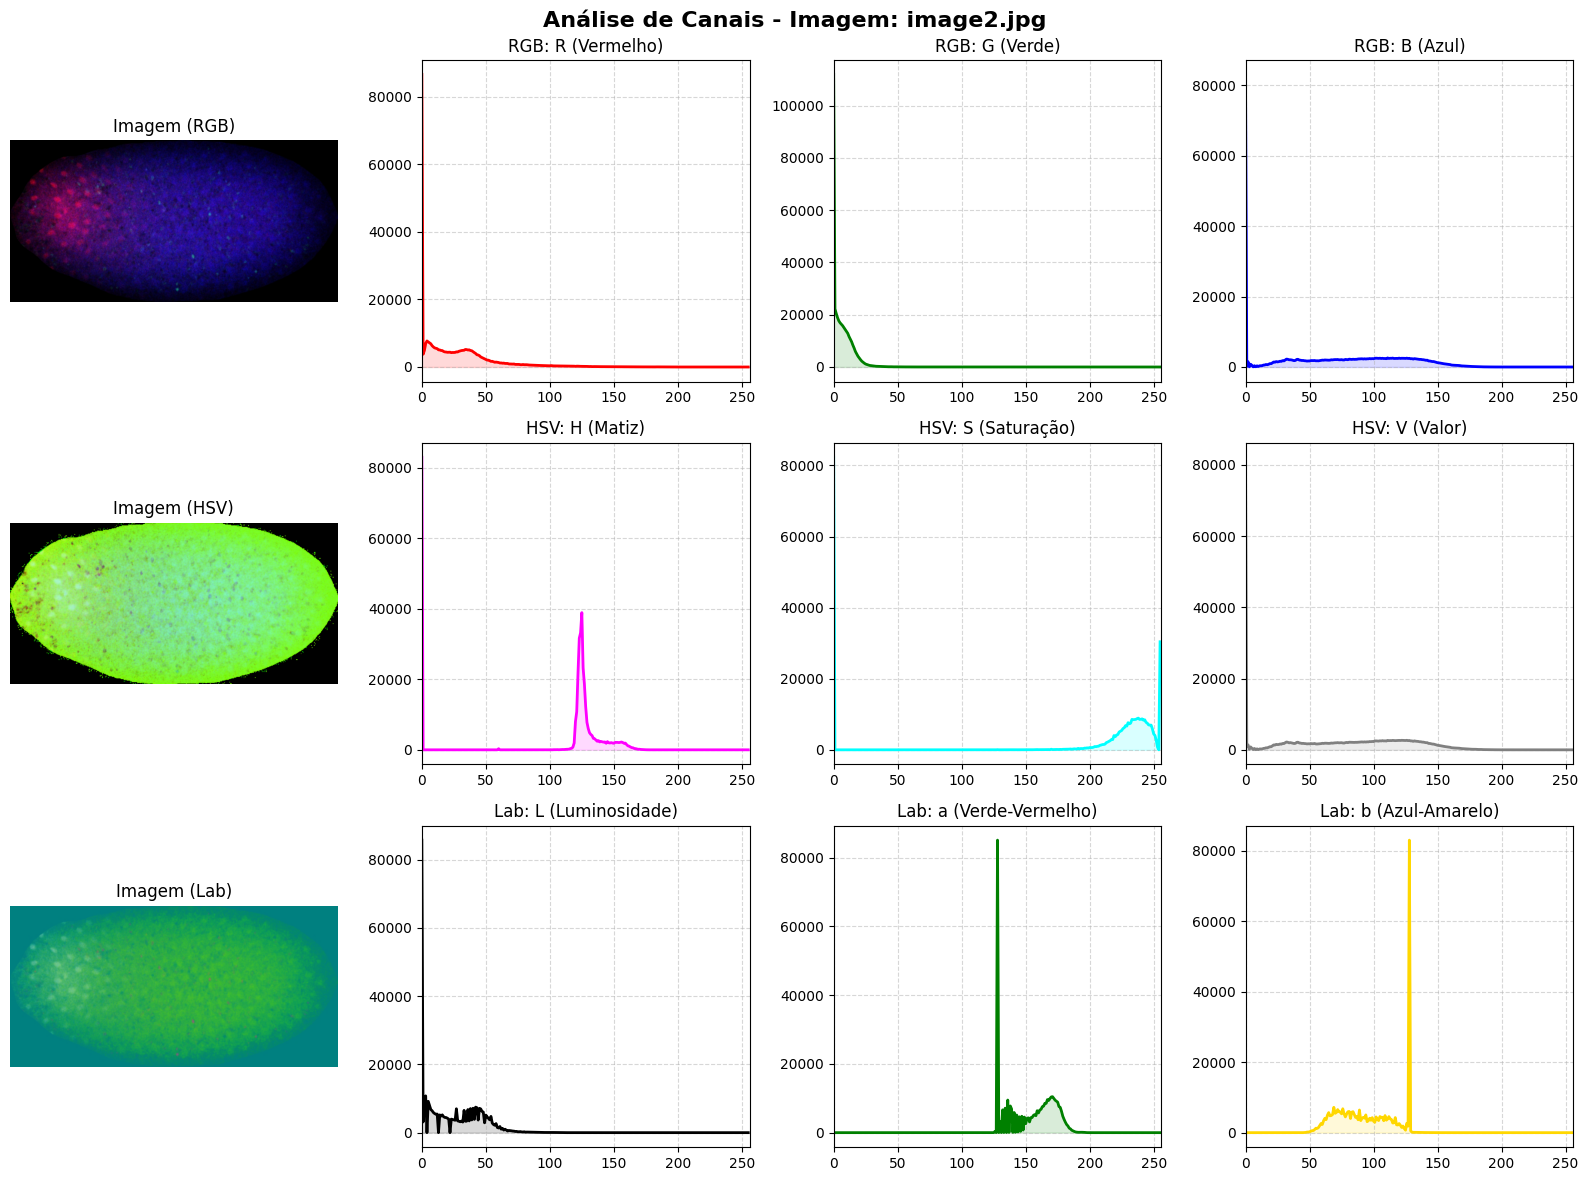

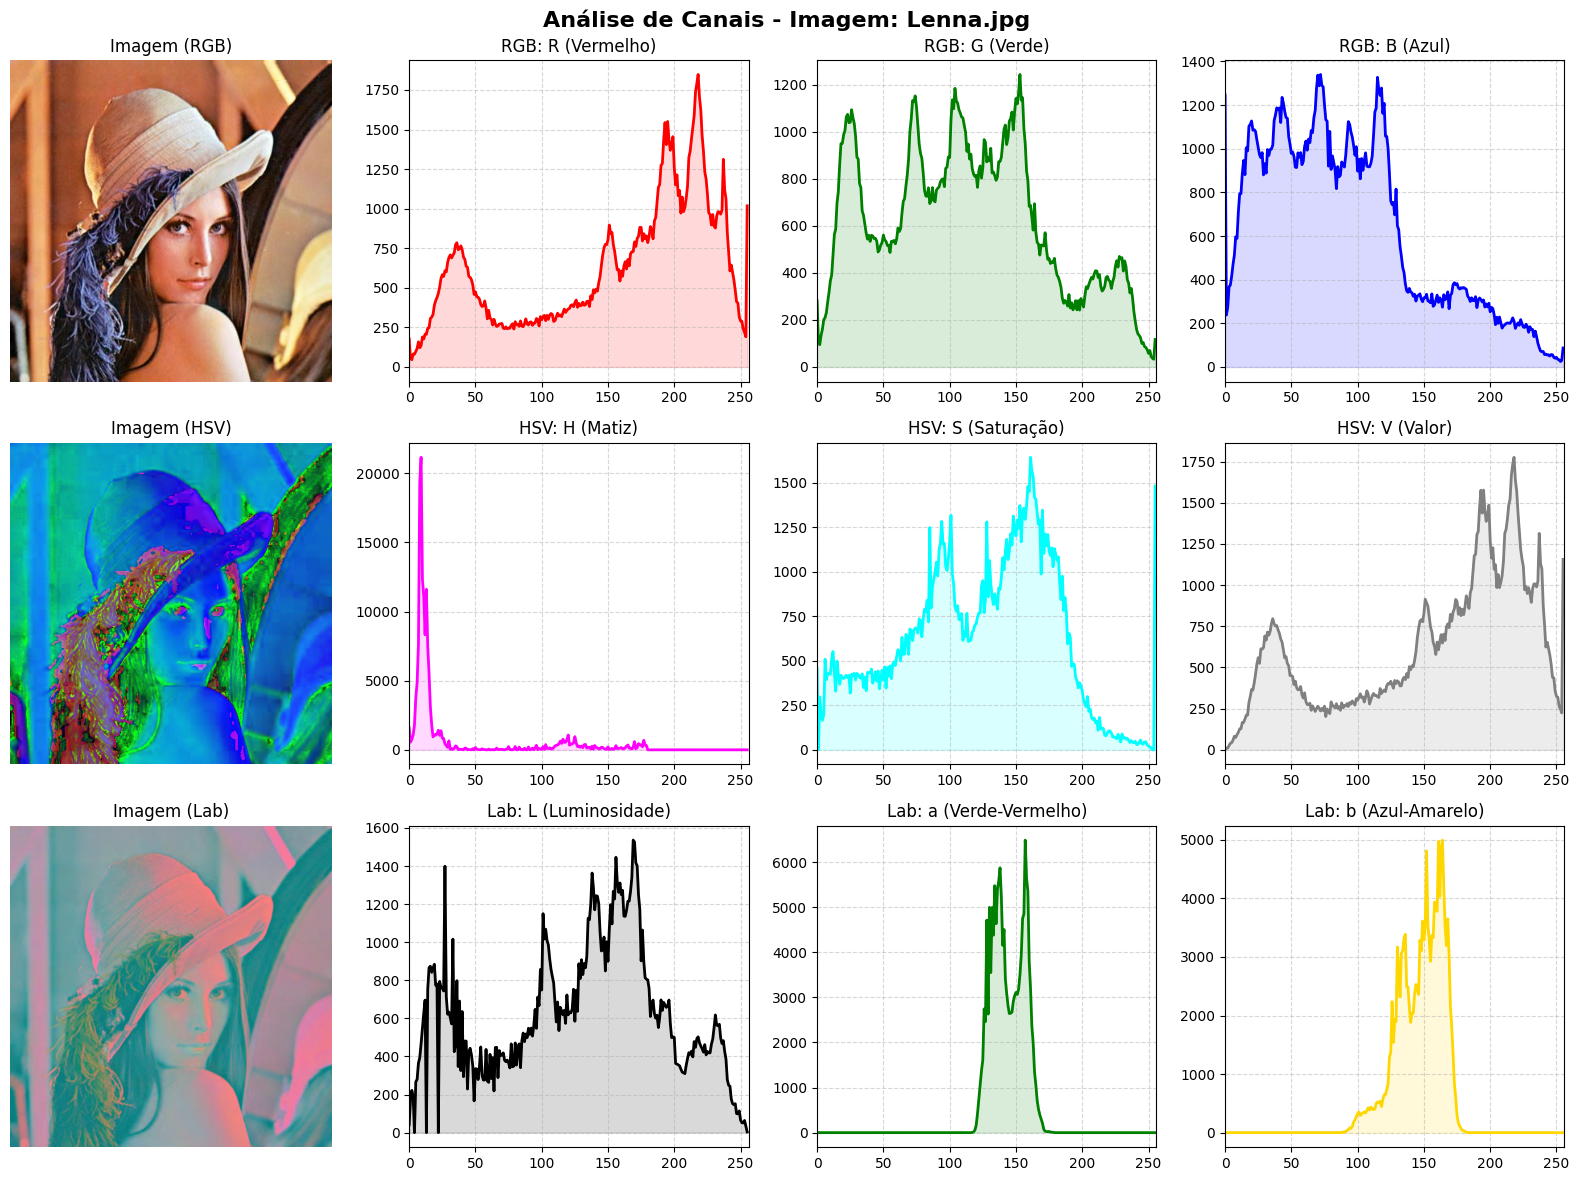

In [12]:
imgArray = np.array(["image.jpg", "image2.jpg", "Lenna.jpg"])
system = np.array(["RGB", "HSV", "Lab"])

def plotar(img_paths, system_names):
  # Loop 1: Percorre cada imagem física
  for i in range(len(img_paths)):
    img_bgr = cv2.imread(img_paths[i], cv2.IMREAD_COLOR)
    
    # Criamos a grade 3x4 (uma figura por imagem)
    fig, eixos = plt.subplots(3, 4, figsize=(16, 12))
    nome_imagem = img_paths[i].split("/")[-1]
    fig.suptitle(f"Análise de Canais - Imagem: {nome_imagem}", fontsize=16, fontweight='bold')

    # Loop 2: Percorre cada um dos 3 sistemas de cores (linhas da grade)
    for j in range(len(system_names)):
      espaco = system_names[j]
      
      # Conversões para RGB, HSV e Lab
      if espaco == "RGB":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        cores_plot = ["red", "green", "blue"]
        nomes_canais = ["R (Vermelho)", "G (Verde)", "B (Azul)"]
      elif espaco == "HSV":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        cores_plot = ["magenta", "cyan", "gray"]
        nomes_canais = ["H (Matiz)", "S (Saturação)", "V (Valor)"]
      elif espaco == "Lab":
        img_convertida = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
        cores_plot = ["black", "green", "gold"]
        nomes_canais = ["L (Luminosidade)", "a (Verde-Vermelho)", "b (Azul-Amarelo)"]
      else:
        continue

      # Eixo [j, 0]: Exibe a imagem convertida na linha j, coluna 0
      eixos[j, 0].imshow(img_convertida)
      eixos[j, 0].axis('off')
      eixos[j, 0].set_title(f"Imagem ({espaco})")

      # Eixos [j, canal + 1]: Calcula e plota os histogramas dos 3 canais correspondentes
      for canal in range(3):
        histograma = cv2.calcHist([img_convertida], [canal], None, [256], [0, 256])
        eixos[j, canal + 1].plot(histograma, color=cores_plot[canal], linewidth=2)
        eixos[j, canal + 1].fill_between(range(256), histograma.flatten(), color=cores_plot[canal], alpha=0.15)
        eixos[j, canal + 1].set_title(f"{espaco}: {nomes_canais[canal]}")
        eixos[j, canal + 1].set_xlim([0, 256])
        eixos[j, canal + 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
  
plotar(imgArray, system)

2)	Utilizando a imagem do mandrill, faça rotinas para detecção do focinho (região vermelha e azul). Utilize algum algoritmo de limiarização.

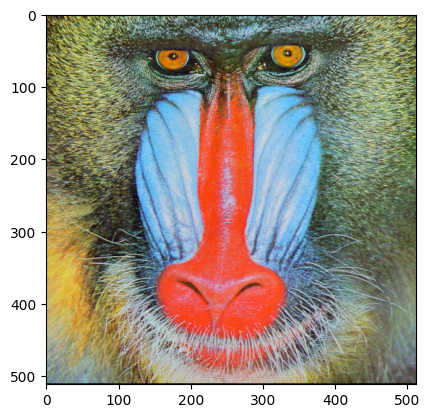

In [10]:
img_mand = cv2.imread("mandrill.tiff", cv2.IMREAD_COLOR)
img_mand_RGB = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img_mand_RGB);


3)	Utilizando a imagem HE.jpg, tente detectar e contar a quantidade de núcleos celulares (em azul). Aplicar o Ostu para os 9 canais de cores e avaliar qual foi melhor (R,G,B,H,S,V,L,a,b)

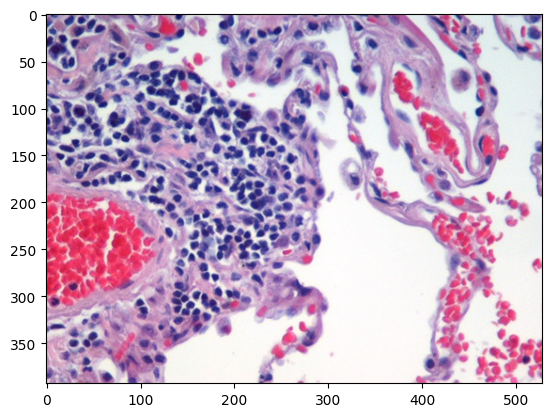

In [15]:
img_he = cv2.imread("HE.jpg", cv2.IMREAD_COLOR)
img_he_RGB = cv2.cvtColor(img_he, cv2.COLOR_BGR2RGB)
plt.imshow(img_he_RGB);